<a href="https://colab.research.google.com/github/AmitabhDey-byte/Project3/blob/main/gdg_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

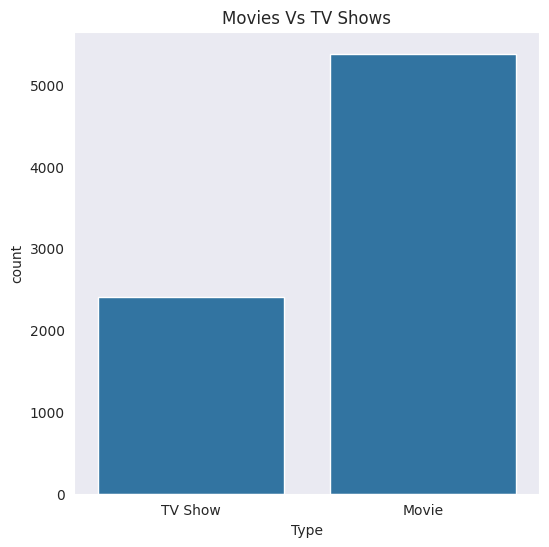

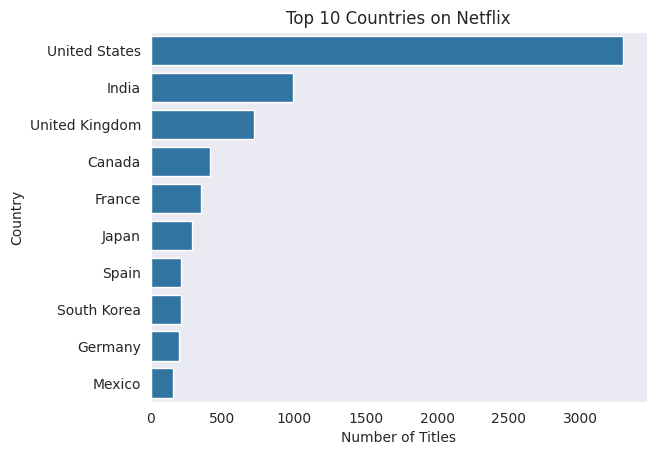

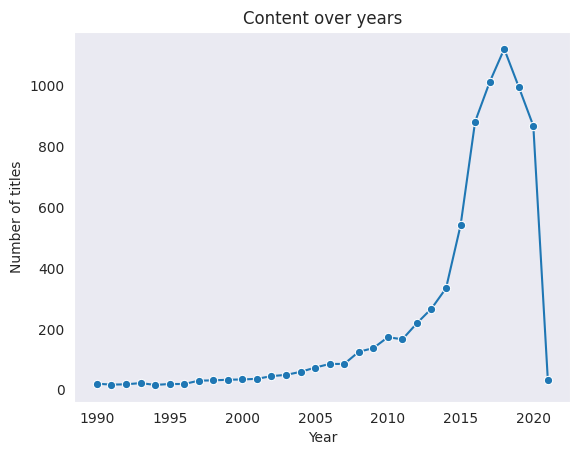

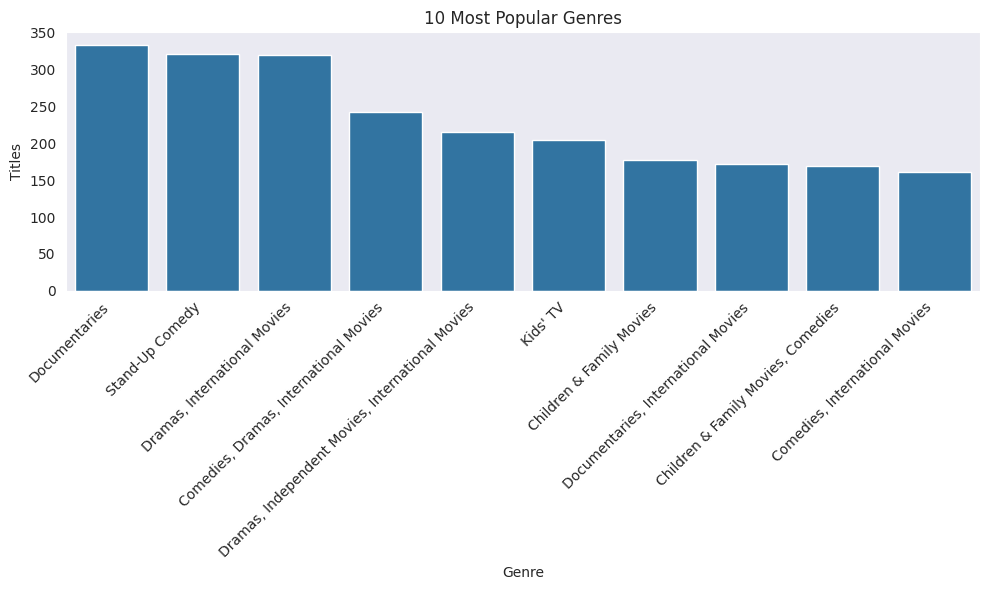

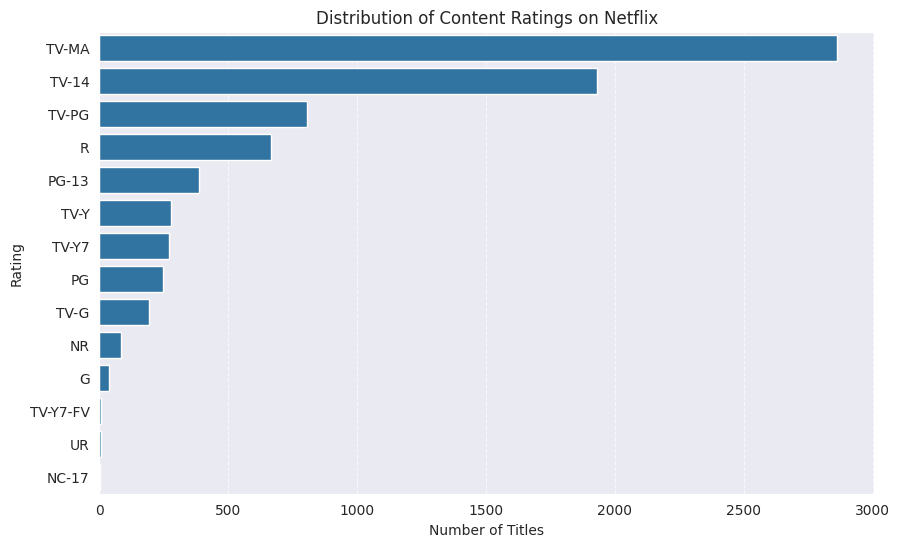

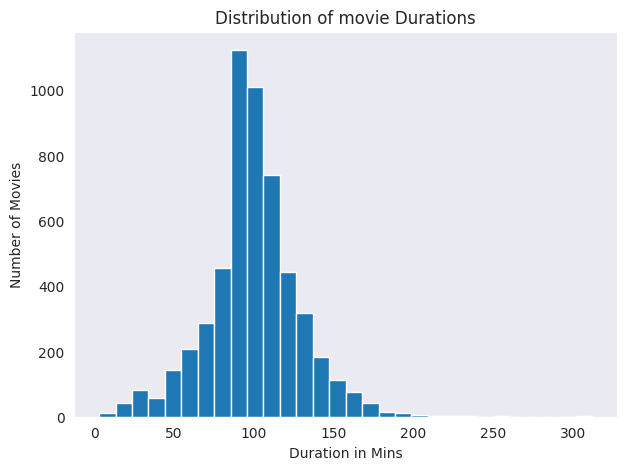

In [6]:
import numpy as np
import seaborn as sea
import pandas as pd
import matplotlib.pyplot as plt

ingest = pd.read_csv("/content/sample_data/NetFlix.csv")

df = ingest.loc[:, ~ingest.columns.str.contains('^Unnamed')]

#fist visualiztion (Movie and TV Shows)
plt.figure(figsize=(6,6))
sea.countplot(x='type', data=df)

plt.title("Movies Vs TV Shows")
plt.xlabel("Type")
plt.ylabel("count")
plt.show()

#2nd Visualization Content by Country -- konse country ka kitna content
country_counting = df['country'].str.split(', ').explode().value_counts().head(10)


sea.barplot(x=country_counting.values, y=country_counting.index)
sea.set_style("dark")
plt.title("Top 10 Countries on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

#3rd Visualizition :content over years

year_counting = df['release_year'].value_counts().sort_index()
years = np.arange(1990, year_counting.index.max() + 1)

year_counting = year_counting.reindex(years, fill_value=0)

sea.lineplot(x=year_counting.index, y=year_counting.values, marker= 'o')
plt.title("Content over years")
plt.xlabel("Year")
plt.ylabel("Number of titles")
plt.show()

#4th Visualization : Most popular genres-- categories

genre_counting = df [ 'genres'].value_counts().head(10)

plt.figure(figsize=(10,6))
sea.barplot(x=genre_counting.index, y=genre_counting.values)
plt.title("10 Most Popular Genres")
plt.xlabel("Genre")
plt.ylabel("Titles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#5th Visualization :Rating Distribution-- like ADULT oriented h ya cool for everyon

plt.figure(figsize=(10,6))
sea.countplot(y='rating',data=df,order=df['rating'].value_counts().index)

plt.title("Distribution of Content Ratings on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

#6th Visualization: Movie Durations

movies = df[df['type'] == 'Movie'].copy()

plt.figure(figsize=(7,5))
plt.hist(movies['duration'], bins=30)

plt.title("Distribution of movie Durations")
plt.xlabel("Duration in Mins")
plt.ylabel("Number of Movies")

plt.show()

